In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("uber-raw-data-apr14.csv")
df.head()

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


In [3]:
df.shape

(564516, 4)

In [4]:
df.columns

Index(['Date/Time', 'Lat', 'Lon', 'Base'], dtype='object')

In [5]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

In [6]:
df['Hour']    = df['Date/Time'].dt.hour
df['Day']     = df['Date/Time'].dt.day
df['Weekday'] = df['Date/Time'].dt.day_name()

In [7]:
df.isnull().sum()

Date/Time    0
Lat          0
Lon          0
Base         0
Hour         0
Day          0
Weekday      0
dtype: int64

In [8]:
df.describe()

,Date/Time,Lat,Lon,Hour,Day
count,564516,564516.000000,564516.000000,564516.000000,564516.000000
mean,2014-04-16 17:46:01.296261120,40.740005,-73.976817,14.465043,16.117127
min,2014-04-01 00:00:00,40.072900,-74.773300,0.000000,1.000000
25%,2014-04-08 16:27:00,40.722500,-73.997700,10.000000,8.000000
50%,2014-04-16 19:19:00,40.742500,-73.984800,16.000000,16.000000
75%,2014-04-24 22:14:00,40.760700,-73.970000,19.000000,24.000000
max,2014-04-30 23:59:00,42.116600,-72.066600,23.000000,30.000000
std,NaN,0.036083,0.050426,5.873925,9.048139


C:\Users\Sumana Reddy\AppData\Local\Temp\ipykernel_3168\1708449355.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hour', data=df, palette='Blues_d')


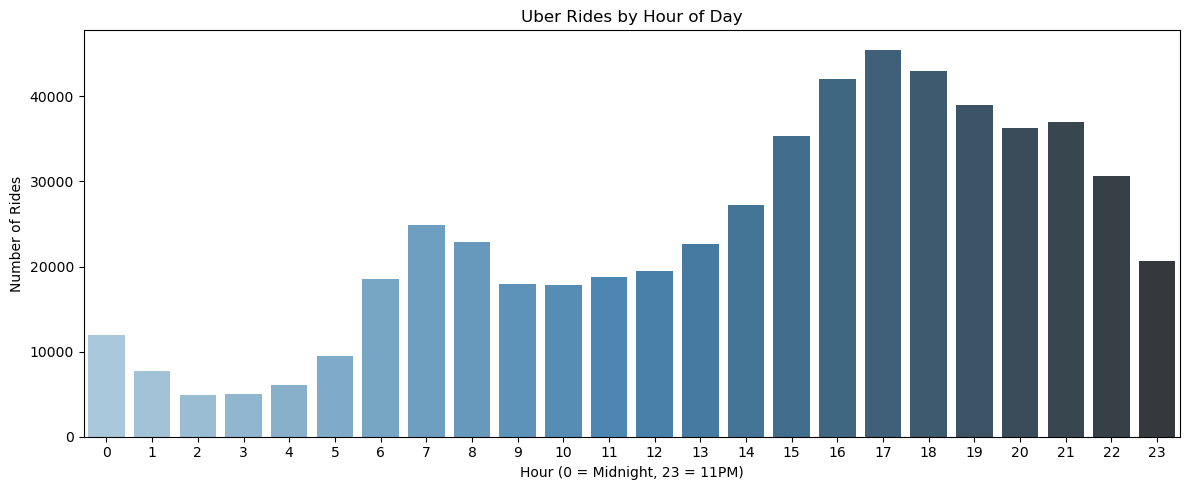

In [9]:
plt.figure(figsize=(12, 5))
sns.countplot(x='Hour', data=df, palette='Blues_d')
plt.title('Uber Rides by Hour of Day')
plt.xlabel('Hour (0 = Midnight, 23 = 11PM)')
plt.ylabel('Number of Rides')
plt.tight_layout()
plt.savefig('peak_hours.png')
plt.show()

In [10]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

C:\Users\Sumana Reddy\AppData\Local\Temp\ipykernel_3168\1723560478.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Weekday', data=df,order=day_order, palette='coolwarm')


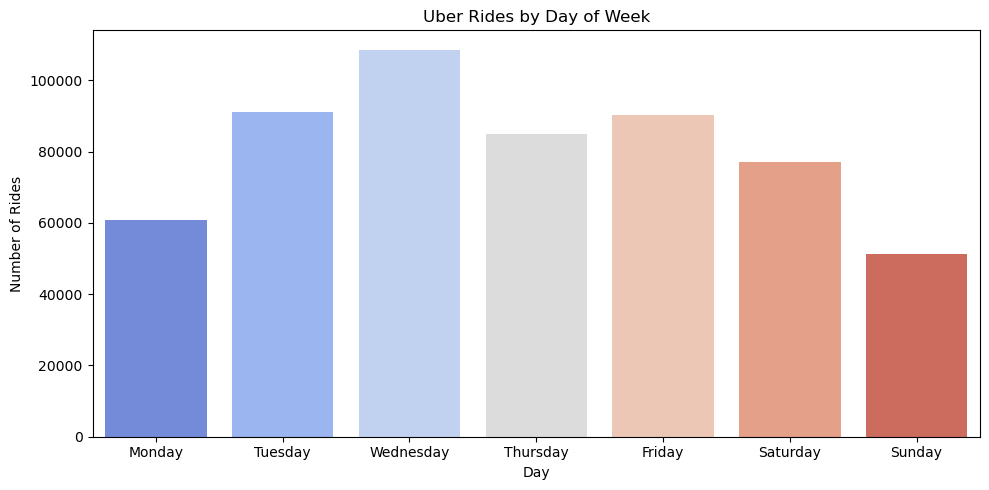

In [11]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Weekday', data=df,order=day_order, palette='coolwarm')
plt.title('Uber Rides by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Rides')
plt.tight_layout()
plt.savefig('busiest_day.png')
plt.show()

In [12]:
daily_rides = df.groupby('Day').size().reset_index(name='Rides')

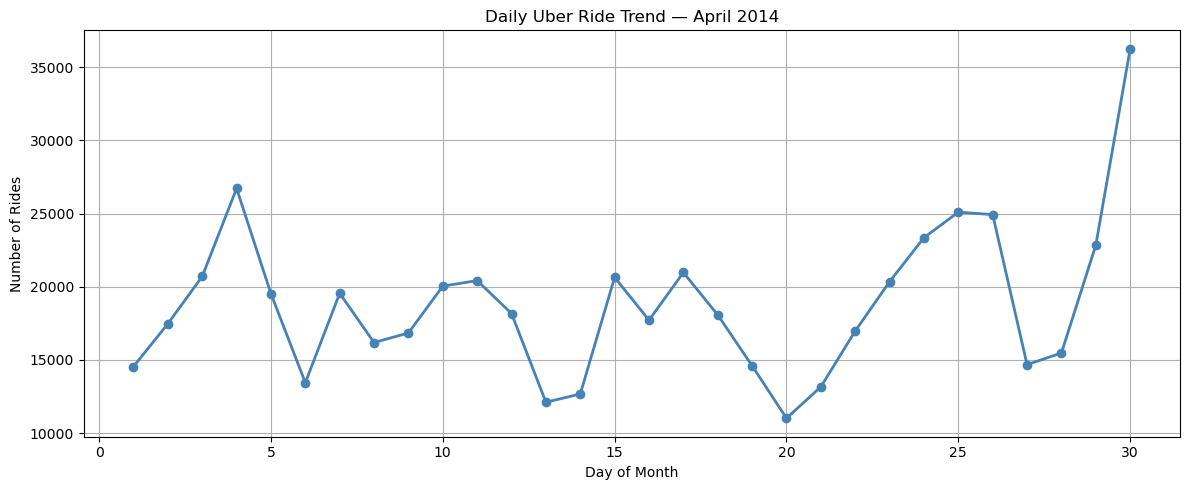

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(daily_rides['Day'], daily_rides['Rides'],marker='o', color='steelblue', linewidth=2)
plt.title('Daily Uber Ride Trend — April 2014')
plt.xlabel('Day of Month')
plt.ylabel('Number of Rides')
plt.grid(True)
plt.tight_layout()
plt.savefig('daily_trend.png')
plt.show()

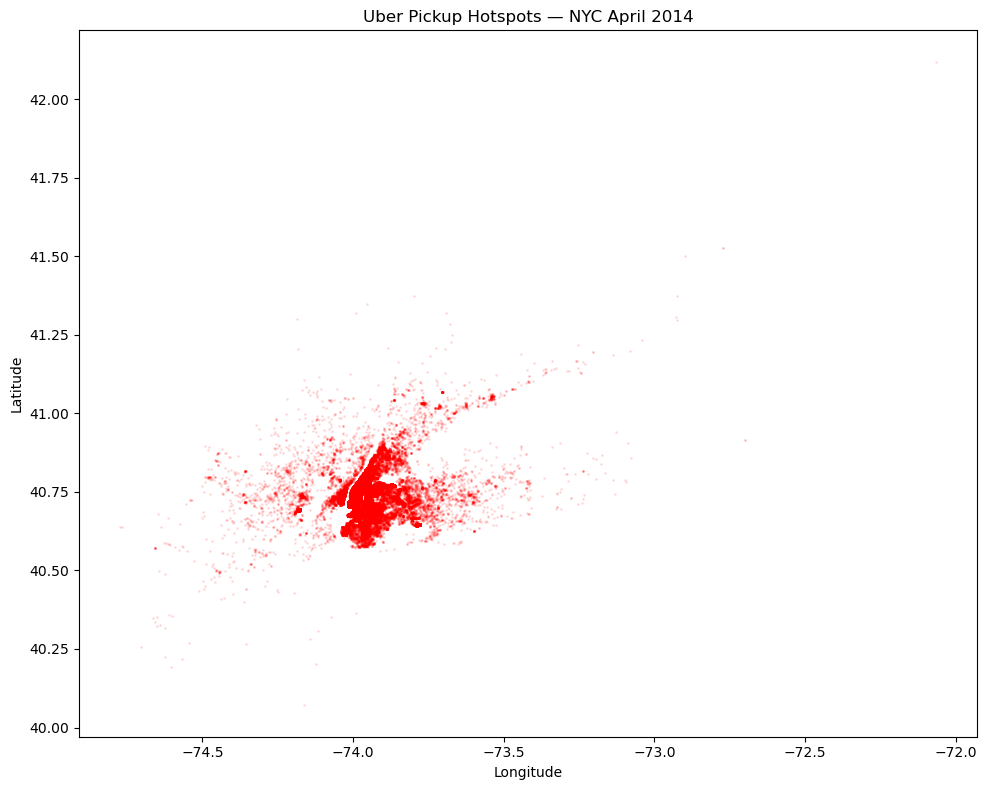

In [14]:
plt.figure(figsize=(10, 8))
plt.scatter(df['Lon'], df['Lat'],alpha=0.1, s=1, color='red')
plt.title('Uber Pickup Hotspots — NYC April 2014')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.savefig('hotspot_map.png')
plt.show()

In [15]:
peak_hour = df['Hour'].value_counts().idxmax()
print(f"Peak Hour: {peak_hour}:00")

Peak Hour: 17:00


In [16]:
busiest_day = df['Weekday'].value_counts().idxmax()
print(f"Busiest Day: {busiest_day}")

Busiest Day: Wednesday


In [17]:
print(f"Total Rides in April 2014: {len(df):,}")

Total Rides in April 2014: 564,516


In [18]:
print(f"Average Rides Per Day: {len(df)//30:,}")

Average Rides Per Day: 18,817
